# Importing Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [4]:
# Set display options
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'
plt.style.use('fivethirtyeight')

# Loading Dataset

In [5]:
# Behaviour datasets configuration
dataset_1 = "Mask Wearing.csv"
target_1 = "mask_wearing"

dataset_2 = "Hand Washing.csv"
target_2 = "wash_hands"

dataset_3 = "Avoid Crowded Areas.csv"
target_3 = "avoid_crowded_areas"

dataset_4 = "Self Isolation.csv"
target_4 = "willingness_self_isolate"

In [6]:
# Load and prepare daily data
def load_and_prepare_var_data(dataset, target):
    """
    Loads the behaviour dataset and converts it into daily-level
    multivariate time-series data for VAR modelling.
    """

    df = pd.read_csv(dataset)

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values("date")

    var_variables = [
        target,

        # Perception variables
        "covid_dangerous_for_me",
        "likely_to_get_covid",
        "trust_in_government_handling",
        "important_to_improve_health",
        "life_affected_by_covid",

        # Policy variables
        "mask_policy",
        "gathering_restriction",
        "cancel_public_events",
        "stay_home_requirement",
        "public_information_campaign",
        "testing_policy",
        "contact_tracing",
        "stringency_index",

        # Epidemiological variables
        "new_cases_smoothed",
        "new_deaths_smoothed",
        "reproduction_rate",
        "hospital_patients",
        "people_fully_vaccinated_per_hundred",

        # Interaction variables
        "policy_x_cases",
        "risk_x_trust"
    ]

    # Keep only columns available in the selected dataset
    var_variables = [
        col for col in var_variables
        if col in df.columns
    ]

    daily_df = (
        df.groupby("date")[var_variables]
        .mean()
        .reset_index()
    )

    daily_df = daily_df.set_index("date")

    daily_df = daily_df.asfreq("D")

    daily_df = daily_df.ffill().bfill()

    print("Dataset loaded successfully")
    print("Daily VAR dataset shape:", daily_df.shape)
    print("Target variable:", target)
    print("Variables used in VAR model:", var_variables)

    return daily_df, var_variables

# VAR Model

In [7]:
# Check stationarity
def check_stationarity_for_var(data):
    """
    Performs ADF test for each variable in the VAR dataset.
    Constant variables are skipped because ADF test cannot be applied to constant series.
    """

    stationarity_results = []

    print("Stationarity Check")

    for column in data.columns:

        series = data[column].dropna()

        # Skip variables that are constant across time
        if series.nunique() <= 1:
            stationarity_results.append({
                "Variable": column,
                "ADF Statistic": np.nan,
                "p-value": np.nan,
                "Status": "Constant - skipped"
            })
            continue

        try:
            result = adfuller(series)

            p_value = result[1]

            if p_value < 0.05:
                status = "Stationary"
            else:
                status = "Non-stationary"

            stationarity_results.append({
                "Variable": column,
                "ADF Statistic": result[0],
                "p-value": p_value,
                "Status": status
            })

        except Exception as e:
            stationarity_results.append({
                "Variable": column,
                "ADF Statistic": np.nan,
                "p-value": np.nan,
                "Status": f"ADF failed: {e}"
            })

    stationarity_df = pd.DataFrame(stationarity_results)

    print(stationarity_df)

    return stationarity_df


# Remove constant variables
def remove_constant_variables(data, target):
    """
    Removes variables that are constant across time.
    Constant variables cause errors in ADF testing and VAR modelling.
    The target variable is retained.
    """

    constant_columns = [
        column for column in data.columns
        if data[column].nunique() <= 1 and column != target
    ]

    if len(constant_columns) > 0:
        print("Constant variables removed:")
        print(constant_columns)

        data = data.drop(columns=constant_columns)

    else:
        print("No constant variables found.")

    return data


In [8]:
# Make data stationary
def make_var_data_stationary(data):
    """
    Applies first-order differencing to make the VAR data more stationary.
    VAR usually performs better when the variables are stationary.
    """

    diff_data = data.diff().dropna()

    print("\nDifferenced VAR data shape:", diff_data.shape)

    return diff_data

In [9]:
# Train-test split and scaling
def split_and_scale_var_data(data, train_ratio=0.80):
    """
    Splits VAR data chronologically into training and testing sets
    and scales all variables.
    """

    train_size = int(len(data) * train_ratio)

    train_data = data.iloc[:train_size]
    test_data = data.iloc[train_size:]

    scaler = StandardScaler()

    train_scaled = pd.DataFrame(
        scaler.fit_transform(train_data),
        columns=data.columns,
        index=train_data.index
    )

    test_scaled = pd.DataFrame(
        scaler.transform(test_data),
        columns=data.columns,
        index=test_data.index
    )

    print("\nTrain-Test Split")
    print("Training data shape:", train_scaled.shape)
    print("Testing data shape:", test_scaled.shape)

    return train_scaled, test_scaled, scaler, train_size

In [10]:
# Select best lag order
def select_var_lag_order(train_data, max_lags=14):
    """
    Selects the best lag order for VAR using AIC.
    """

    model = VAR(train_data)

    lag_results = model.select_order(maxlags=max_lags)

    print("\nVAR Lag Order Selection")
    print(lag_results.summary())

    selected_lag = lag_results.aic

    if selected_lag is None or selected_lag == 0:
        selected_lag = 1

    print("\nSelected lag order:", selected_lag)

    return selected_lag

In [11]:
# Train VAR model
def train_var_model(train_data, selected_lag):
    """
    Trains the VAR model using the selected lag order.
    """

    model = VAR(train_data)

    result = model.fit(selected_lag)

    print("\nVAR Model Summary")
    print(result.summary())

    return result

In [12]:
# Test-period one-step prediction
def predict_var_test_period(train_data, test_data, selected_lag):
    """
    Performs one-step-ahead prediction over the test period.
    This uses observed previous values, so it is prediction,
    not future forecasting.
    """

    full_data = pd.concat([train_data, test_data])

    predictions = []

    for i in range(len(test_data)):

        current_position = len(train_data) + i

        history = full_data.iloc[
            current_position - selected_lag:current_position
        ].values

        model = VAR(full_data.iloc[:current_position])

        result = model.fit(selected_lag)

        pred = result.forecast(
            y=history,
            steps=1
        )

        predictions.append(pred[0])

    predictions_df = pd.DataFrame(
        predictions,
        columns=test_data.columns,
        index=test_data.index
    )

    return predictions_df

In [13]:
# Inverse transform predictions
def inverse_transform_var_results(train_data, test_data, predictions, scaler):
    """
    Converts scaled VAR predictions back to the original scale.
    """

    test_original = pd.DataFrame(
        scaler.inverse_transform(test_data),
        columns=test_data.columns,
        index=test_data.index
    )

    predictions_original = pd.DataFrame(
        scaler.inverse_transform(predictions),
        columns=predictions.columns,
        index=predictions.index
    )

    return test_original, predictions_original

In [14]:
# Convert differenced predeictions back to level
def restore_original_scale(original_data, test_original_diff, predictions_original_diff, train_size):
    """
    Converts differenced predictions back to the original level values
    so accuracy can be calculated on the actual target scale.
    """

    test_start_position = train_size + 1

    actual_values = original_data.iloc[test_start_position:].copy()

    previous_values = original_data.iloc[test_start_position - 1:-1].copy()

    predicted_level = previous_values.copy()

    for column in predictions_original_diff.columns:
        predicted_level[column] = (
            previous_values[column].values +
            predictions_original_diff[column].values
        )

    actual_level = actual_values[predictions_original_diff.columns]

    actual_level.index = predictions_original_diff.index
    predicted_level.index = predictions_original_diff.index

    return actual_level, predicted_level

In [15]:
# Evaluate model
def evaluate_var_model(actual, predicted, target):
    """
    Calculates accuracy metrics for the target variable.
    R-squared is not included because it is not required for this analysis.
    """

    y_test = actual[target]

    y_pred = predicted[target]

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_test, y_pred)

    mape = mean_absolute_percentage_error(y_test, y_pred)

    results = pd.DataFrame({
        "Model": ["VAR"],
        "MSE": [mse],
        "RMSE": [rmse],
        "MAE": [mae],
        "MAPE": [mape]
    })

    print("\nVAR Accuracy Results")
    print(results)

    return results

In [16]:
# Plot results
def plot_var_results(original_data, actual, predicted, target, train_size):
    """
    Plots the complete training series, actual test data,
    VAR predicted values, actual vs predicted plot,
    and residual plot with clear colours.
    """

    train_actual = original_data[target].iloc[:train_size]

    y_test = actual[target]

    y_pred = predicted[target]

    # Full time-series plot: training, actual test and prediction
    plt.figure(figsize=(16, 7))

    plt.plot(
        train_actual.index,
        train_actual,
        label="Training Data",
        color="#1f77b4",
        linewidth=2
    )

    plt.plot(
        y_test.index,
        y_test,
        label="Actual Test Data",
        color="#ff7f0e",
        linewidth=2.5
    )

    plt.plot(
        y_pred.index,
        y_pred,
        label="VAR Predicted Values",
        color="#d62728",
        linewidth=2.5
    )

    plt.xlabel("Date", fontsize=16)
    plt.ylabel(target.replace("_"," ").title(), fontsize=16)

    plt.legend(fontsize=12, loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Actual vs predicted values
    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_pred,
        color="#1f77b4",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Perfect prediction line"
    )

    plt.xlabel("Actual Values", fontsize=14)
    plt.ylabel("Predicted Values", fontsize=14)

    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Residual plot
    residuals = y_test - y_pred

    plt.figure(figsize=(14, 5))

    plt.plot(
        residuals.index,
        residuals,
        color="#1f77b4",
        linewidth=2
    )

    plt.axhline(
        y=0,
        color="red",
        linestyle="--",
        linewidth=2
    )
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Residuals", fontsize=14)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [17]:
# VAR pipeline
def run_var_pipeline(dataset, target):
    """
    Runs the complete VAR modelling pipeline.
    """

    original_data, var_variables = load_and_prepare_var_data(
        dataset,
        target
    )

    # Remove constant variables before stationarity testing and VAR modelling
    original_data = remove_constant_variables(
        original_data,
        target
    )

    check_stationarity_for_var(
        original_data
    )

    stationary_data = make_var_data_stationary(
        original_data
    )

    train_data, test_data, scaler, train_size = split_and_scale_var_data(
        stationary_data
    )

    selected_lag = select_var_lag_order(
        train_data
    )

    var_result = train_var_model(
        train_data,
        selected_lag
    )

    predictions_scaled = predict_var_test_period(
        train_data,
        test_data,
        selected_lag
    )

    test_original_diff, predictions_original_diff = inverse_transform_var_results(
        train_data,
        test_data,
        predictions_scaled,
        scaler
    )

    actual_level, predicted_level = restore_original_scale(
        original_data,
        test_original_diff,
        predictions_original_diff,
        train_size
    )

    accuracy_results = evaluate_var_model(
        actual_level,
        predicted_level,
        target
    )

    plot_var_results(
        original_data,
        actual_level,
        predicted_level,
        target,
        train_size
    )

    return var_result, accuracy_results

# Results

Dataset loaded successfully
Daily VAR dataset shape: (727, 21)
Target variable: mask_wearing
Variables used in VAR model: ['mask_wearing', 'covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'mask_policy', 'gathering_restriction', 'cancel_public_events', 'stay_home_requirement', 'public_information_campaign', 'testing_policy', 'contact_tracing', 'stringency_index', 'new_cases_smoothed', 'new_deaths_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']
Constant variables removed:
['public_information_campaign', 'contact_tracing']
Stationarity Check
                               Variable  ADF Statistic   p-value  \
0                          mask_wearing      -4.857201  0.000042   
1                covid_dangerous_for_me      -2.938015  0.041103   
2                   likely_to_get_covid      -2.652087  0.082702   
3          trust

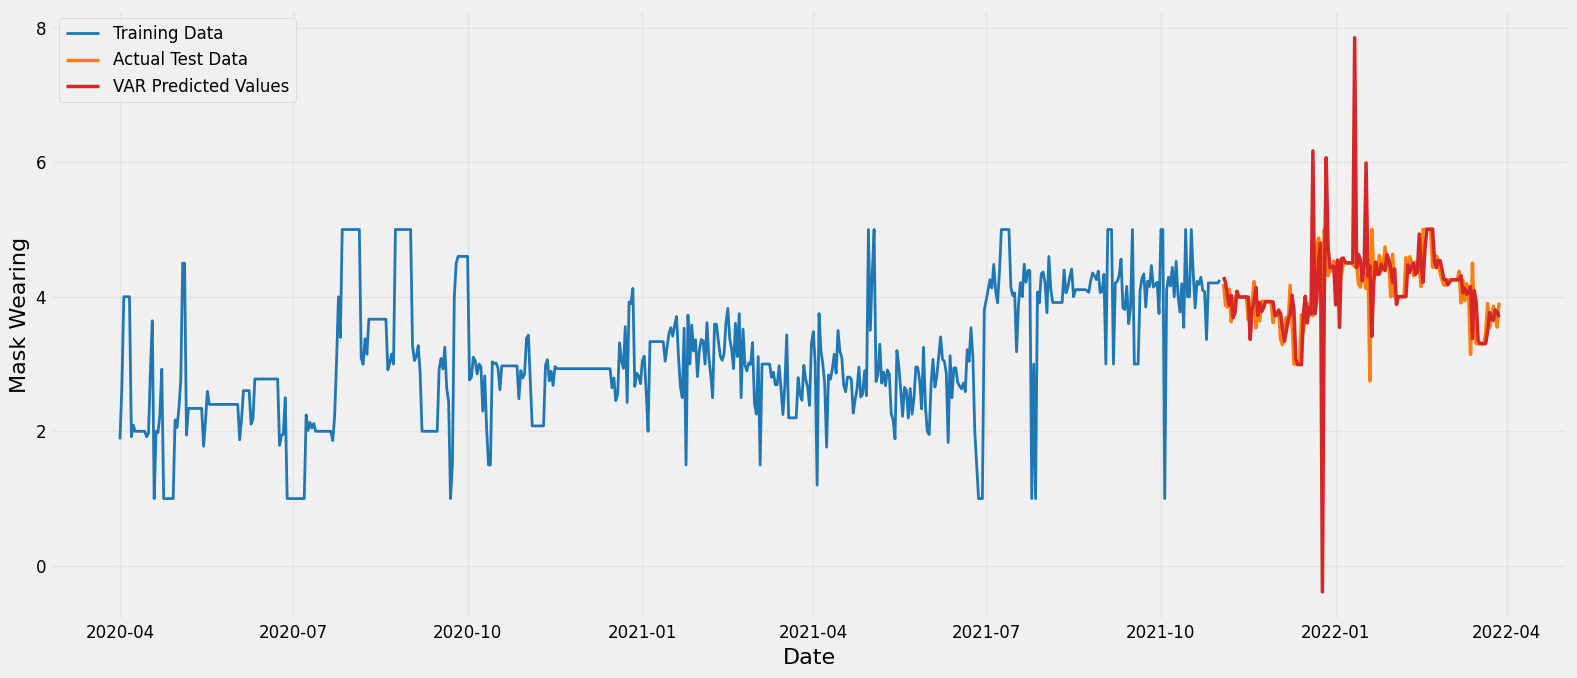

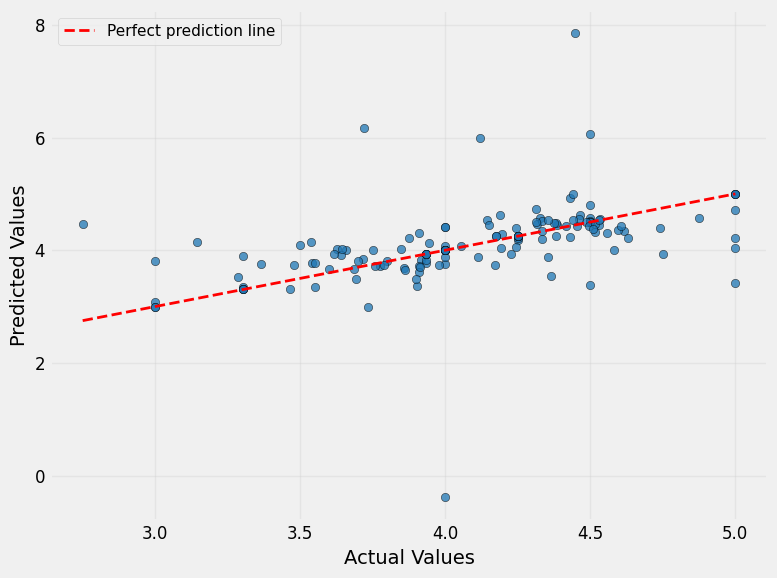

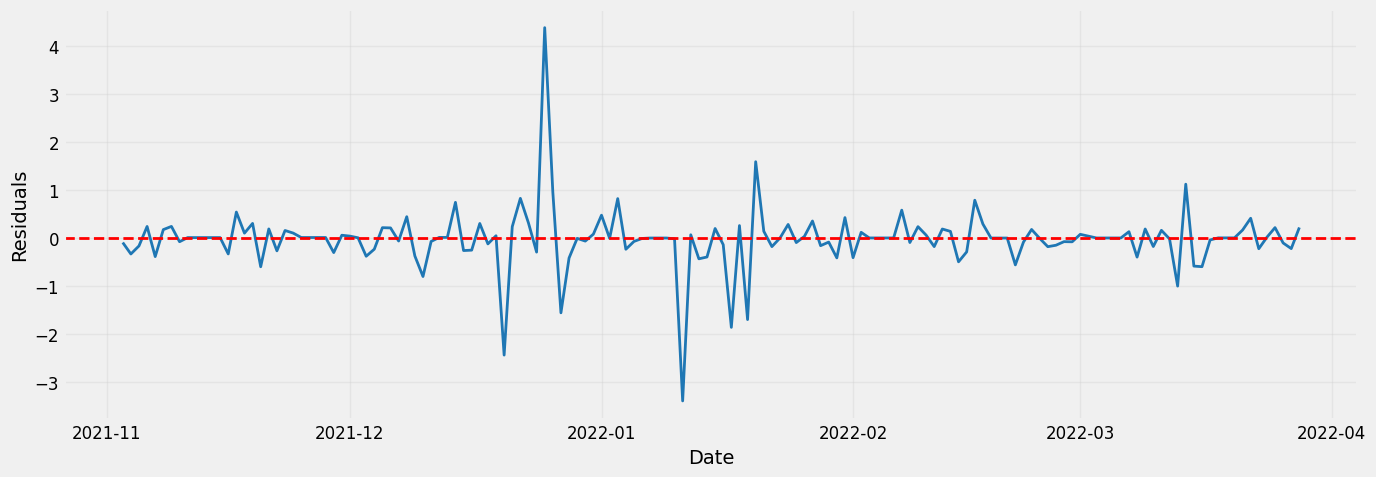

In [18]:
# Run model for mask wearing
mask_model, mask_accuracy = run_var_pipeline(
    dataset_1,
    target_1
)

Dataset loaded successfully
Daily VAR dataset shape: (715, 21)
Target variable: wash_hands
Variables used in VAR model: ['wash_hands', 'covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'mask_policy', 'gathering_restriction', 'cancel_public_events', 'stay_home_requirement', 'public_information_campaign', 'testing_policy', 'contact_tracing', 'stringency_index', 'new_cases_smoothed', 'new_deaths_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']
Constant variables removed:
['public_information_campaign', 'contact_tracing']
Stationarity Check
                               Variable  ADF Statistic       p-value  \
0                            wash_hands      -9.293927  1.159765e-15   
1                covid_dangerous_for_me      -2.911555  4.402066e-02   
2                   likely_to_get_covid      -2.678454  7.784138e-02   
3   

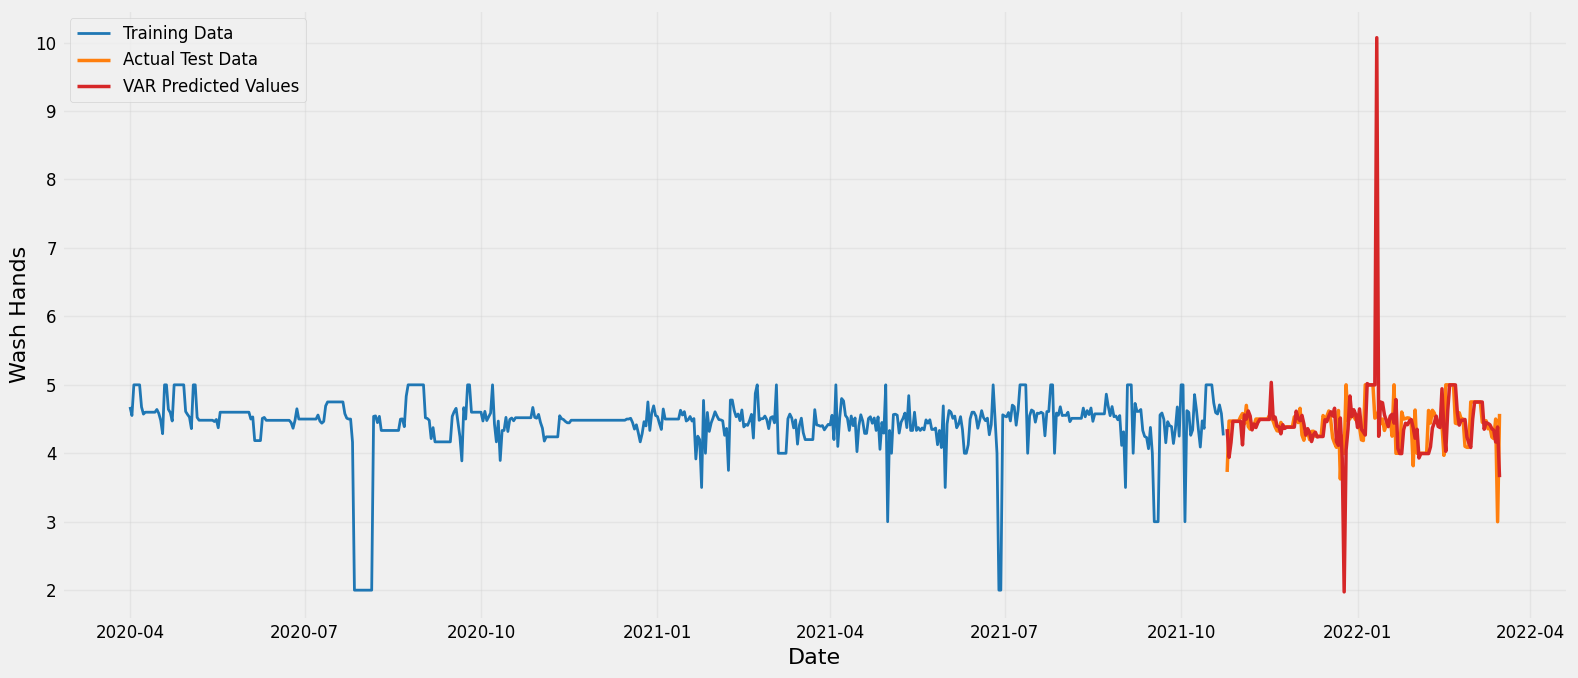

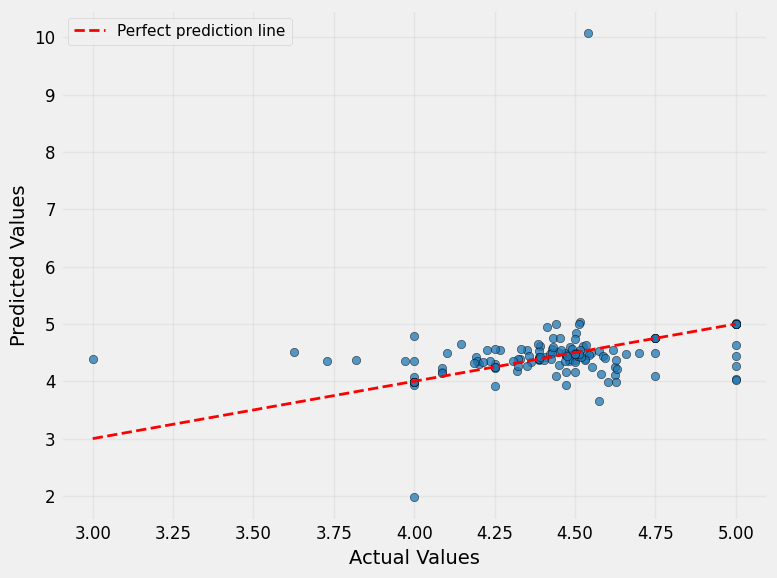

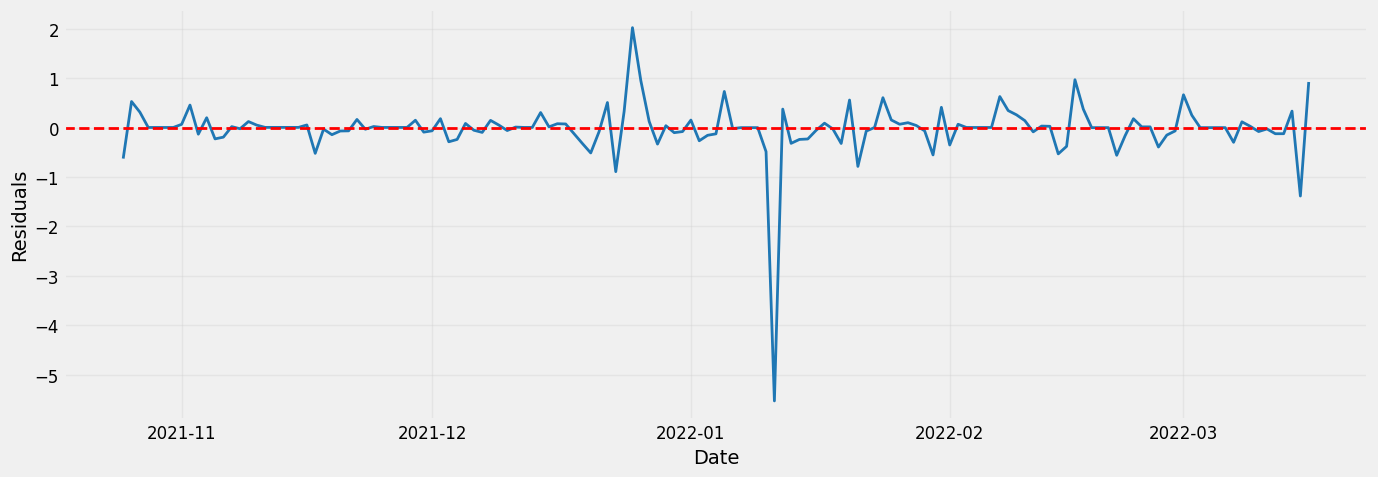

In [19]:
# Run model for hand washing
handwashing_model, handwashing_accuracy = run_var_pipeline(
    dataset_2,
    target_2
)

Dataset loaded successfully
Daily VAR dataset shape: (727, 21)
Target variable: avoid_crowded_areas
Variables used in VAR model: ['avoid_crowded_areas', 'covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'mask_policy', 'gathering_restriction', 'cancel_public_events', 'stay_home_requirement', 'public_information_campaign', 'testing_policy', 'contact_tracing', 'stringency_index', 'new_cases_smoothed', 'new_deaths_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']
Constant variables removed:
['public_information_campaign', 'contact_tracing']
Stationarity Check
                               Variable  ADF Statistic       p-value  \
0                   avoid_crowded_areas      -7.202062  2.351458e-10   
1                covid_dangerous_for_me      -2.938015  4.110263e-02   
2                   likely_to_get_covid      -2.652087  8.

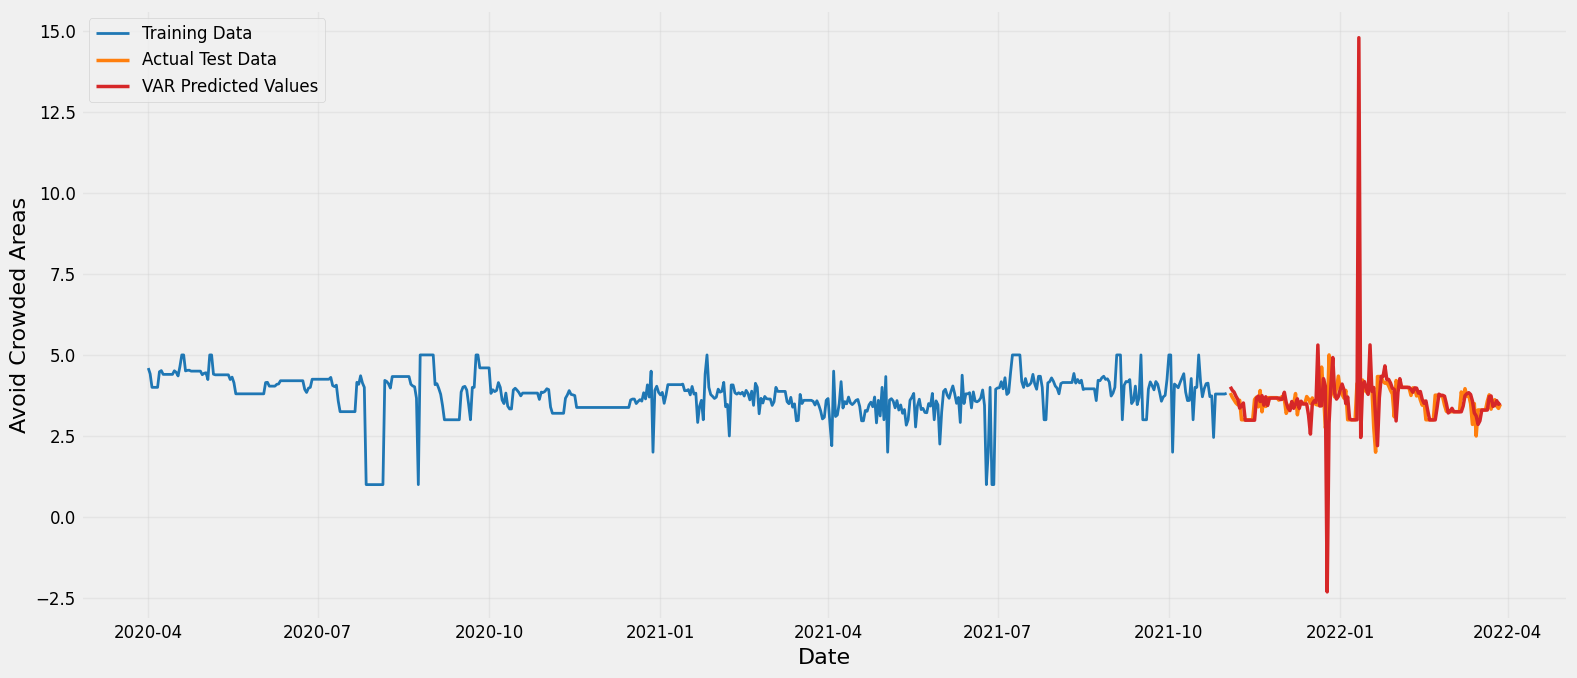

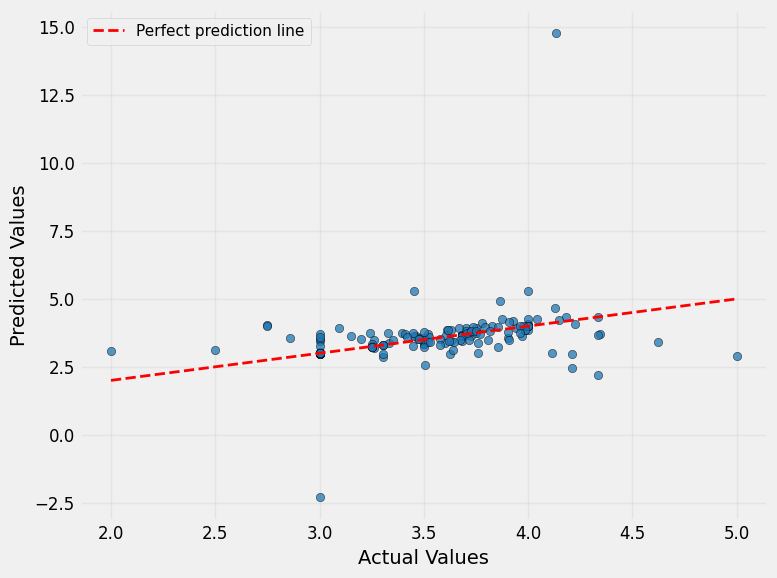

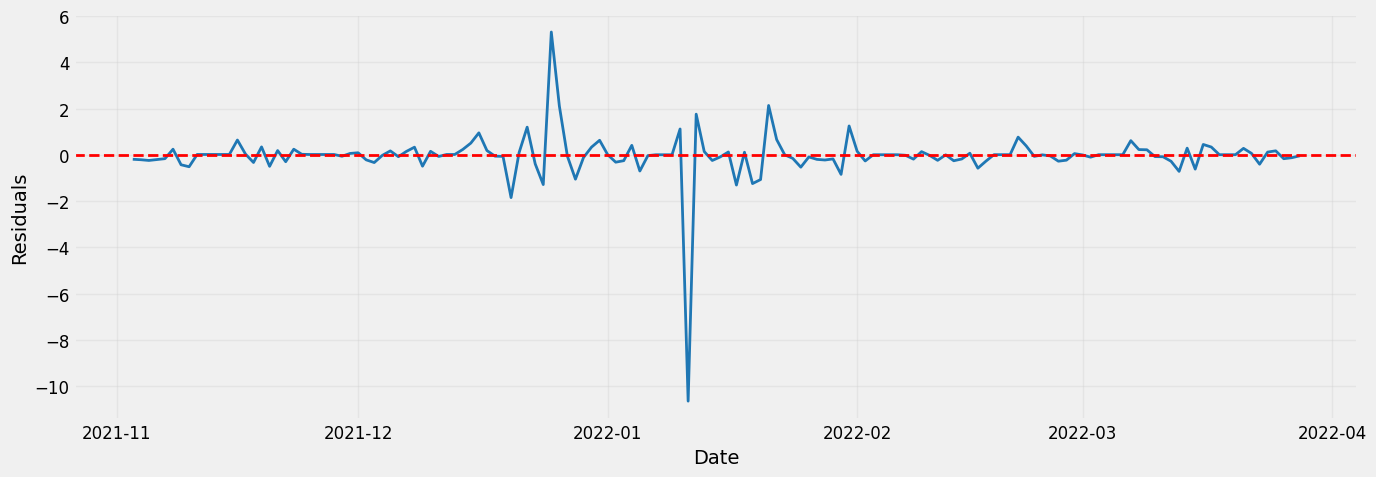

In [20]:
# Run model for Avoid Crowded Areas
crowded_model, crowded_accuracy = run_var_pipeline(
    dataset_3,
    target_3
)

Dataset loaded successfully
Daily VAR dataset shape: (727, 21)
Target variable: willingness_self_isolate
Variables used in VAR model: ['willingness_self_isolate', 'covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'mask_policy', 'gathering_restriction', 'cancel_public_events', 'stay_home_requirement', 'public_information_campaign', 'testing_policy', 'contact_tracing', 'stringency_index', 'new_cases_smoothed', 'new_deaths_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']
Constant variables removed:
['public_information_campaign', 'contact_tracing']
Stationarity Check
                               Variable  ADF Statistic       p-value  \
0              willingness_self_isolate      -6.449164  1.538822e-08   
1                covid_dangerous_for_me      -2.864597  4.962245e-02   
2                   likely_to_get_covid      -2.

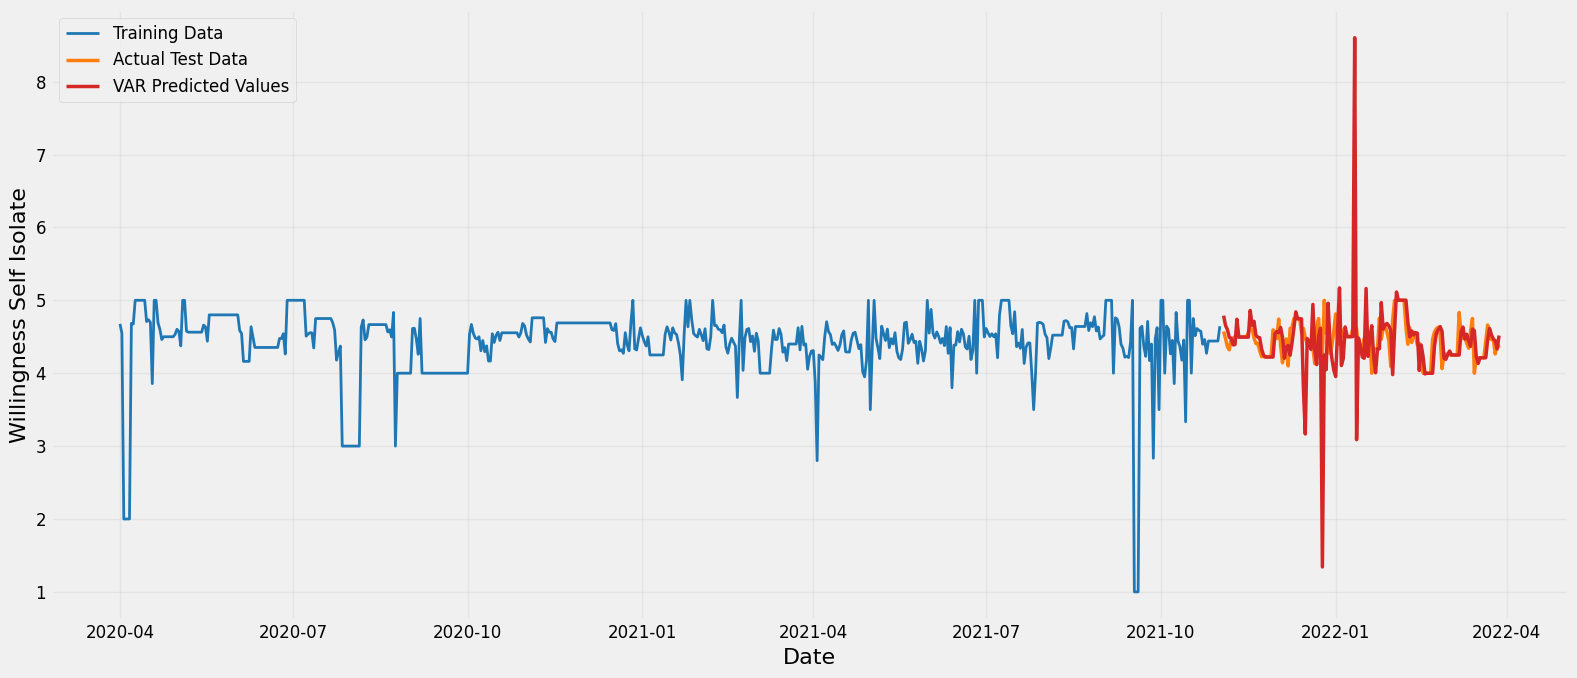

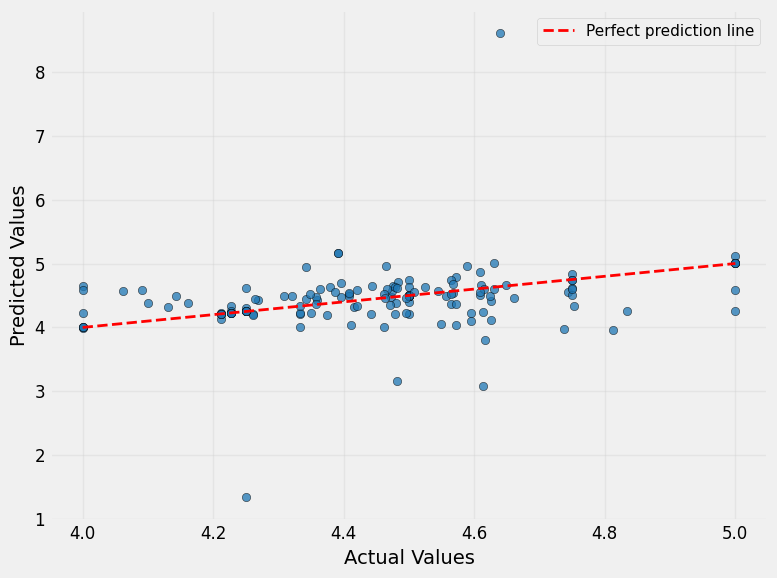

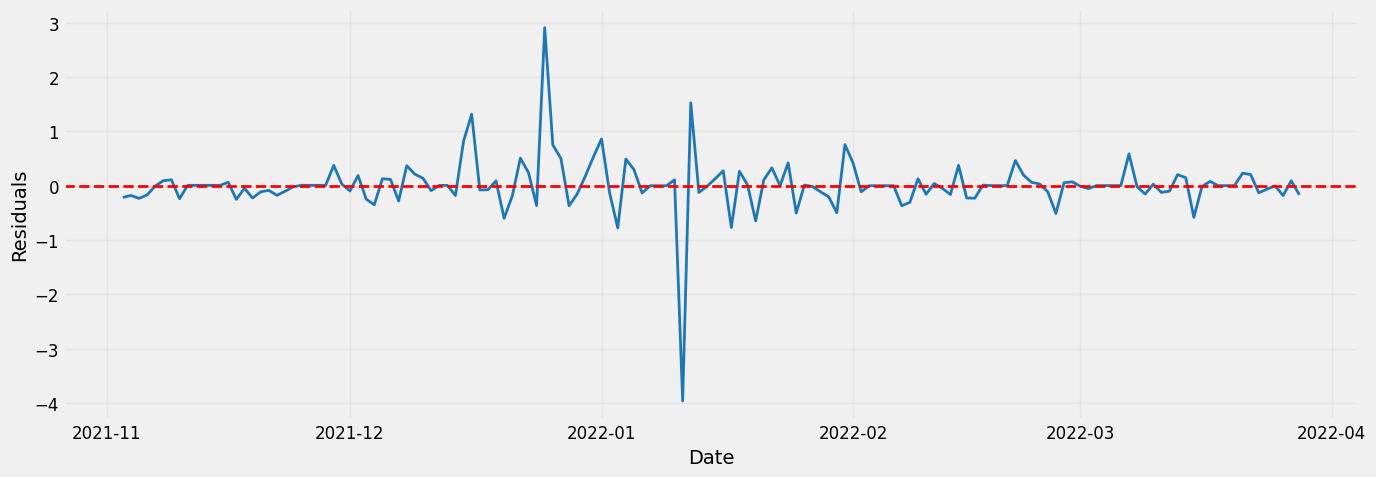

In [21]:
# Run model for self isolation
self_model, self_accuracy = run_var_pipeline(
    dataset_4,
    target_4
)

In [22]:
# Combine VAR results for all 4 outcomes
var_results_table = pd.concat(
    [
        mask_accuracy,
        handwashing_accuracy,
        crowded_accuracy,
        self_accuracy
    ],
    ignore_index=True
)

var_results_table.insert(
    0,
    "Outcome Variable",
    [
        "Mask Wearing",
        "Hand Washing",
        "Avoid Crowded Areas",
        "Self Isolation"
    ]
)

var_results_table

,Outcome Variable,Model,MSE,RMSE,MAE,MAPE
0,Mask Wearing,VAR,0.423139,0.650491,0.316419,0.078977
1,Hand Washing,VAR,0.340389,0.583428,0.246265,0.056851
2,Avoid Crowded Areas,VAR,1.227347,1.107857,0.404929,0.112777
3,Self Isolation,VAR,0.265628,0.515391,0.244037,0.054530
